In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder

from sklearn.datasets import load_iris

In [39]:
class Pca_from_scratch:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.eigenvalues = None  

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        cov_matrix = np.cov(X_centered, rowvar=False)

        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

        
        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.eigenvalues = eigenvalues[sorted_indices]       
        self.components = eigenvectors[:, sorted_indices[:self.n_components]]

    def transform(self, X):
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [41]:
class GaussianNB_scratch:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.priors = {}

        for c in self.classes:
            X_c = X[y == c]
            self.mean[c] = np.mean(X_c, axis=0)
            self.var[c] = np.var(X_c, axis=0)
            self.priors[c] = X_c.shape[0] / X.shape[0]

    def _gaussian_likelihood(self, x, mean, var):
        eps = 1e-9  
        coeff = 1 / np.sqrt(2 * np.pi * var + eps)
        exponent = np.exp(-0.5 * ((x - mean) ** 2) / (var + eps))
        return coeff * exponent

    def _predict_single(self, x):
        posteriors = {}
        for c in self.classes:
            prior = np.log(self.priors[c])
            likelihood = np.sum(np.log(self._gaussian_likelihood(x, self.mean[c], self.var[c])))
            posteriors[c] = prior + likelihood
        return max(posteriors, key=posteriors.get)

    def predict(self, X):
        return np.array([self._predict_single(x) for x in X])

In [59]:
class CategoricalNB_scratch:
    def fit(self, X, y, alpha=1.0):
        X = np.array(X)   
        y = np.array(y)   
        
        self.classes = np.unique(y)
        self.priors = {}
        self.likelihoods = {}

        for c in self.classes:
            X_c = X[y == c]
            self.priors[c] = X_c.shape[0] / X.shape[0]
            self.likelihoods[c] = {}

            for feature in range(X.shape[1]):
                categories = np.unique(X[:, feature])
                self.likelihoods[c][feature] = {}
                for cat in categories:
                    count = np.sum(X_c[:, feature] == cat)
                    self.likelihoods[c][feature][cat] = (count + alpha) / (X_c.shape[0] + alpha * len(categories))

    def _predict_single(self, x):
        posteriors = {}
        for c in self.classes:
            posterior = np.log(self.priors[c])
            for feature in range(len(x)):
                cat = x[feature]
                if cat in self.likelihoods[c][feature]:
                    posterior += np.log(self.likelihoods[c][feature][cat])
            posteriors[c] = posterior
        return max(posteriors, key=posteriors.get)

    def predict(self, X):
        X = np.array(X)   
        return np.array([self._predict_single(x) for x in X])

In [43]:
from ucimlrepo import fetch_ucirepo


mushroom = fetch_ucirepo(id=73)

X = mushroom.data.features
y = mushroom.data.targets


print("Data types:")
print(X.dtypes)


print("\nMissing values per column:")
print(X.isna().sum())

print("\nMissing values % per column:")
print(X.isna().mean() * 100)

Data types:
cap-shape                   object
cap-surface                 object
cap-color                   object
bruises                     object
odor                        object
gill-attachment             object
gill-spacing                object
gill-size                   object
gill-color                  object
stalk-shape                 object
stalk-root                  object
stalk-surface-above-ring    object
stalk-surface-below-ring    object
stalk-color-above-ring      object
stalk-color-below-ring      object
veil-type                   object
veil-color                  object
ring-number                 object
ring-type                   object
spore-print-color           object
population                  object
habitat                     object
dtype: object

Missing values per column:
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attach

In [44]:
y.value_counts()

poisonous
e            4208
p            3916
Name: count, dtype: int64

In [45]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [46]:
X[X['stalk-root'].isnull()]

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
3984,x,y,b,t,n,f,c,b,e,e,NaN,s,s,e,w,p,w,t,e,w,c,w
4023,x,y,e,f,y,f,c,n,b,t,NaN,k,s,w,w,p,w,o,e,w,v,p
4076,f,y,u,f,n,f,c,n,h,e,NaN,s,f,w,w,p,w,o,f,h,y,d
4100,x,y,e,f,y,f,c,n,b,t,NaN,k,s,p,p,p,w,o,e,w,v,d
4104,x,y,n,f,f,f,c,n,b,t,NaN,s,s,p,p,p,w,o,e,w,v,l
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,k,s,n,f,n,a,c,b,y,e,NaN,s,s,o,o,p,o,o,p,b,c,l
8120,x,s,n,f,n,a,c,b,y,e,NaN,s,s,o,o,p,n,o,p,b,v,l
8121,f,s,n,f,n,a,c,b,n,e,NaN,s,s,o,o,p,o,o,p,b,c,l
8122,k,y,n,f,y,f,c,n,b,t,NaN,s,k,w,w,p,w,o,e,w,v,l


In [47]:
X['stalk-root'].value_counts()

stalk-root
b    3776
e    1120
c     556
r     192
Name: count, dtype: int64

In [51]:
X['stalk-root'].fillna(X['stalk-root'].mode()[0],inplace=True)

C:\Users\workstation\AppData\Local\Temp\ipykernel_36028\3699527785.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['stalk-root'].fillna(X['stalk-root'].mode()[0],inplace=True)


In [52]:
for col in X.columns:
    print(X[col].value_counts())


cap-shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64
cap-surface
y    3244
s    2556
f    2320
g       4
Name: count, dtype: int64
cap-color
n    2284
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
u      16
r      16
Name: count, dtype: int64
bruises
f    4748
t    3376
Name: count, dtype: int64
odor
n    3528
f    2160
s     576
y     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64
gill-attachment
f    7914
a     210
Name: count, dtype: int64
gill-spacing
c    6812
w    1312
Name: count, dtype: int64
gill-size
b    5612
n    2512
Name: count, dtype: int64
gill-color
b    1728
p    1492
w    1202
n    1048
g     752
h     732
u     492
k     408
e      96
y      86
o      64
r      24
Name: count, dtype: int64
stalk-shape
t    4608
e    3516
Name: count, dtype: int64
stalk-root
b    6256
e    1120
c     556
r     192
Name: count, dtype: int64
stalk-surface-above-ring
s    5176
k    2372
f

In [53]:
for col in X.columns:
    if X[col].nunique() == 1:
        print(col)

veil-type


In [54]:
X = X.drop(columns=['veil-type'])   

In [56]:
encoder = LabelEncoder()
for col in X.columns:
    X[col]=encoder.fit_transform(X[col])
    
encoder_y= LabelEncoder()
y=encoder_y.fit_transform(y)    

In [60]:

X.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,5,2,4,1,6,1,0,1,4,0,2,2,2,7,7,2,1,4,2,3,5
1,5,2,9,1,0,1,0,0,4,0,1,2,2,7,7,2,1,4,3,2,1
2,0,2,8,1,3,1,0,0,5,0,1,2,2,7,7,2,1,4,3,2,3
3,5,3,8,1,6,1,0,1,5,0,2,2,2,7,7,2,1,4,2,3,5
4,5,2,3,0,5,1,1,0,4,1,2,2,2,7,7,2,1,0,3,0,1


CategoricalNB Baseline Accuracy : 0.947076923076923
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       842
           1       0.99      0.90      0.94       783

    accuracy                           0.95      1625
   macro avg       0.95      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625



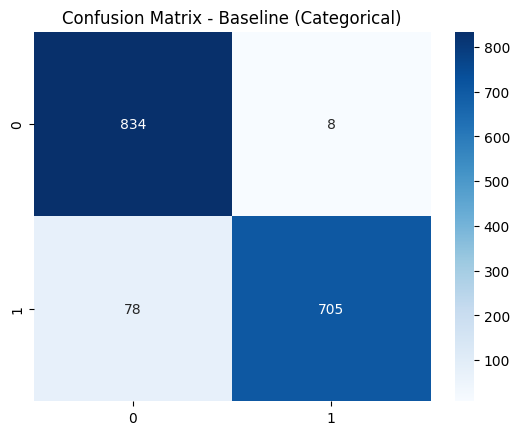

In [61]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
model = CategoricalNB_scratch()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
baseline_acc_categorical = accuracy_score(y_test,y_pred)
print("CategoricalNB Baseline Accuracy :", baseline_acc_categorical)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=encoder_y.classes_, yticklabels=encoder_y.classes_)
plt.title("Confusion Matrix - Baseline (Categorical)")
plt.show()

Selected features: ['bruises', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-root', 'stalk-surface-above-ring', 'ring-type', 'spore-print-color', 'population', 'habitat']
Feature Selection Accuracy: 0.9009230769230769
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       842
           1       0.96      0.83      0.89       783

    accuracy                           0.90      1625
   macro avg       0.91      0.90      0.90      1625
weighted avg       0.91      0.90      0.90      1625



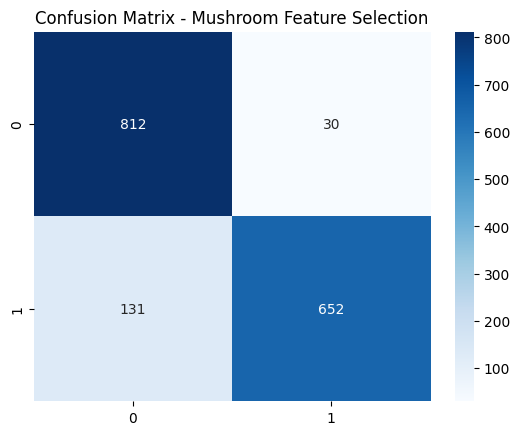

In [63]:
selector = SelectKBest(score_func=chi2, k=10)

selector.fit(X_train, y_train)

selected_features = X.columns[selector.get_support()]
print("Selected features:", selected_features.tolist())  

X_train_fs = selector.transform(X_train)
X_test_fs = selector.transform(X_test)

model_fs = CategoricalNB_scratch()

model_fs.fit(X_train_fs, y_train)

y_pred_fs = model_fs.predict(X_test_fs)

fs_acc_cat = accuracy_score(y_test, y_pred_fs)

print("Feature Selection Accuracy:", fs_acc_cat)
print(classification_report(y_test, y_pred_fs))

cm = confusion_matrix(y_test, y_pred_fs)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=encoder_y.classes_, yticklabels=encoder_y.classes_)
plt.title("Confusion Matrix - Mushroom Feature Selection")
plt.show()

In [64]:
best_acc_cat = 0
best_k_cat = 0

for k in range(1, X.shape[1] + 1):

    pca = Pca_from_scratch(n_components=k)

    pca.fit(X_train.values)                        
    X_train_pca = pca.transform(X_train.values)    
    X_test_pca = pca.transform(X_test.values)      

    model = GaussianNB_scratch()

    model.fit(X_train_pca, y_train)                

    y_pred = model.predict(X_test_pca)

    acc = accuracy_score(y_test, y_pred)          

    if acc > best_acc_cat:
        best_acc_cat = acc
        best_k_cat = k

print("Best PCA k (Categorical):", best_k_cat)
print("Best PCA Accuracy:", best_acc_cat)

Best PCA k (Categorical): 17
Best PCA Accuracy: 0.908923076923077


              precision    recall  f1-score   support

           0       0.88      0.96      0.92       842
           1       0.95      0.86      0.90       783

    accuracy                           0.91      1625
   macro avg       0.91      0.91      0.91      1625
weighted avg       0.91      0.91      0.91      1625



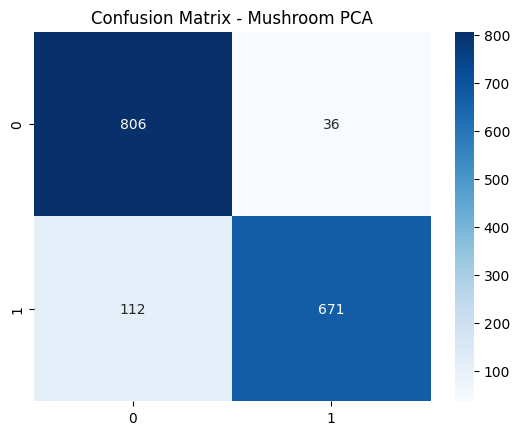

In [66]:
pca = Pca_from_scratch(n_components=best_k_cat)

pca.fit(X_train.values)                        
X_train_pca = pca.transform(X_train.values)    
X_test_pca = pca.transform(X_test.values)      

model = GaussianNB_scratch()

model.fit(X_train_pca, y_train)               

y_pred = model.predict(X_test_pca)

print(classification_report(y_test, y_pred))   

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=encoder_y.classes_, yticklabels=encoder_y.classes_)
plt.title("Confusion Matrix - Mushroom PCA")
plt.show()


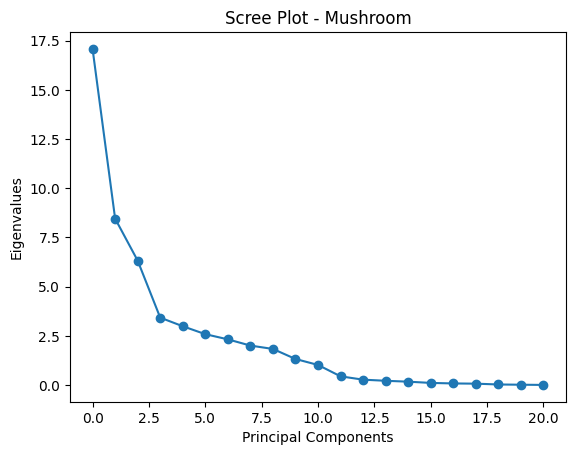

In [67]:
pca = Pca_from_scratch(n_components=X.shape[1])
pca.fit(X.values)

plt.plot(pca.eigenvalues, marker="o")

plt.title("Scree Plot - Mushroom")

plt.xlabel("Principal Components")

plt.ylabel("Eigenvalues")

plt.show()


In [68]:
data = load_iris()

X_num = data.data
y_num = data.target

df_iris = pd.DataFrame(X_num, columns=data.feature_names)

df_iris["target"] = y_num

In [69]:
df_iris.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [70]:
for col in df_iris.columns:

    print(df_iris[col].value_counts())

sepal length (cm)
5.0    10
6.3     9
5.1     9
6.7     8
5.7     8
6.4     7
5.5     7
5.8     7
4.9     6
6.0     6
5.4     6
5.6     6
6.1     6
6.5     5
4.8     5
7.7     4
6.9     4
4.6     4
5.2     4
6.2     4
4.4     3
7.2     3
5.9     3
6.8     3
4.7     2
6.6     2
4.3     1
7.0     1
5.3     1
4.5     1
7.1     1
7.3     1
7.6     1
7.4     1
7.9     1
Name: count, dtype: int64
sepal width (cm)
3.0    26
2.8    14
3.2    13
3.4    12
3.1    11
2.9    10
2.7     9
2.5     8
3.3     6
3.5     6
3.8     6
2.6     5
3.6     4
2.3     4
3.7     3
2.2     3
2.4     3
3.9     2
4.4     1
4.2     1
4.1     1
4.0     1
2.0     1
Name: count, dtype: int64
petal length (cm)
1.4    13
1.5    13
4.5     8
5.1     8
1.3     7
1.6     7
5.6     6
4.9     5
4.0     5
4.7     5
1.7     4
4.8     4
5.0     4
4.4     4
4.2     4
4.1     3
3.9     3
5.8     3
5.7     3
5.5     3
6.1     3
4.6     3
1.9     2
5.2     2
5.4     2
1.2     2
3.3     2
3.5     2
6.7     2
5.3     2
4.3     2
5.9  

In [71]:
df_iris.dropna(inplace=True)

Numerical Baseline Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



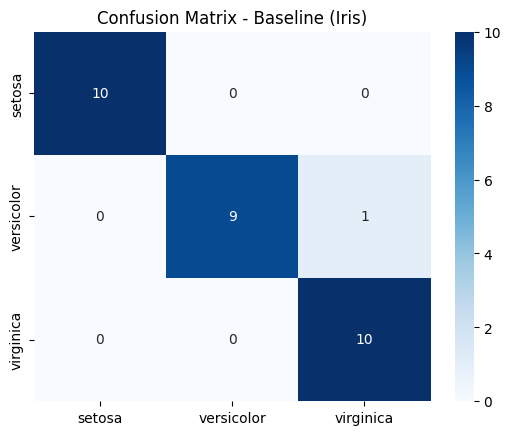

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X_num, y_num, test_size=0.2, random_state=42, stratify=y_num
)

model = GaussianNB_scratch()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

baseline_acc_num = accuracy_score(y_test, y_pred)

print("Numerical Baseline Accuracy:", baseline_acc_num)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=data.target_names, yticklabels=data.target_names)

plt.title("Confusion Matrix - Baseline (Iris)")

plt.show()

Selected features: ['petal length (cm)', 'petal width (cm)']
Feature Selection Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



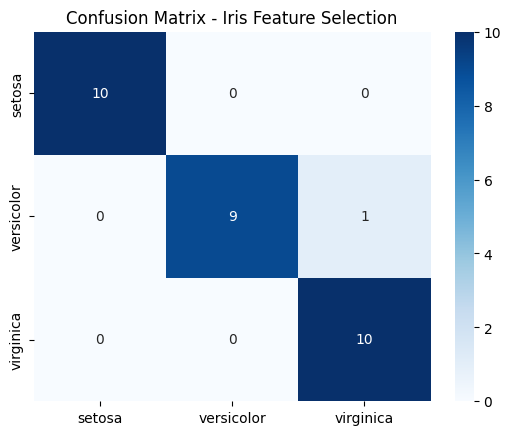

In [74]:
from sklearn.feature_selection import f_classif

selector = SelectKBest(score_func=f_classif, k=2)   

selector.fit(X_train, y_train)

selected_features = [data.feature_names[i] for i in selector.get_support(indices=True)]
print("Selected features:", selected_features)       

X_train_fs = selector.transform(X_train)
X_test_fs = selector.transform(X_test)

model_fs = GaussianNB_scratch()

model_fs.fit(X_train_fs, y_train)

y_pred_fs = model_fs.predict(X_test_fs)

fs_acc_num = accuracy_score(y_test, y_pred_fs)

print("Feature Selection Accuracy:", fs_acc_num)

print(classification_report(y_test, y_pred_fs))

cm = confusion_matrix(y_test, y_pred_fs)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=data.target_names, yticklabels=data.target_names)
plt.title("Confusion Matrix - Iris Feature Selection")
plt.show()


Best PCA k (Numerical): 1
Best PCA Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



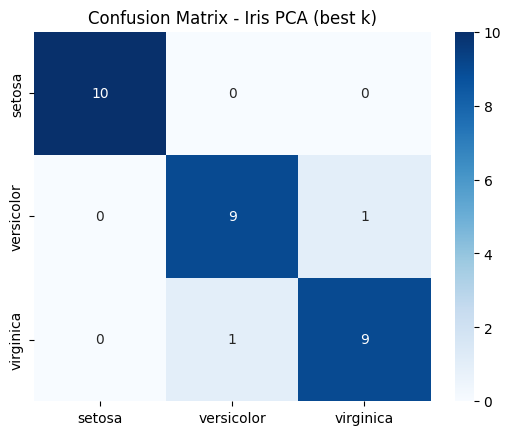

In [75]:
best_acc_num = 0
best_k_num = 0

for k in range(1, X_num.shape[1] + 1):

    pca = Pca_from_scratch(n_components=k)

    pca.fit(X_train)                        
    X_train_pca = pca.transform(X_train)    
    X_test_pca = pca.transform(X_test)      

    model = GaussianNB_scratch()

    model.fit(X_train_pca, y_train)        

    y_pred = model.predict(X_test_pca)

    acc = accuracy_score(y_test, y_pred)    

    if acc > best_acc_num:
        best_acc_num = acc
        best_k_num = k

print("Best PCA k (Numerical):", best_k_num)
print("Best PCA Accuracy:", best_acc_num)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=data.target_names, yticklabels=data.target_names)
plt.title("Confusion Matrix - Iris PCA (best k)")
plt.show()


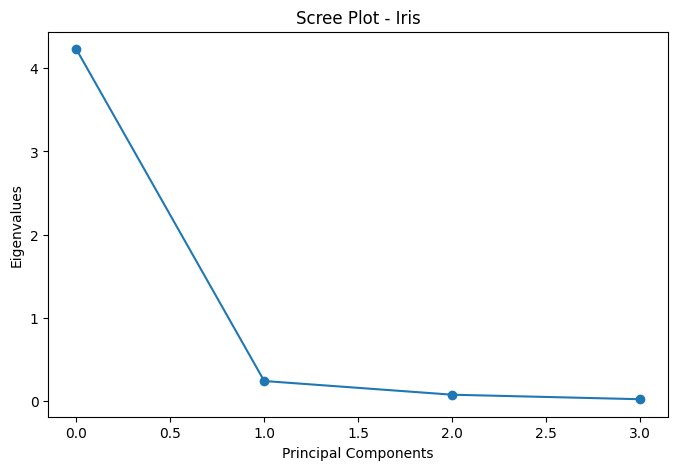

In [76]:
pca_scree = Pca_from_scratch(n_components=X_num.shape[1])
pca_scree.fit(X_num)

plt.figure(figsize=(8, 5))
plt.plot(pca_scree.eigenvalues, marker="o")
plt.title("Scree Plot - Iris")
plt.xlabel("Principal Components")
plt.ylabel("Eigenvalues")
plt.show()

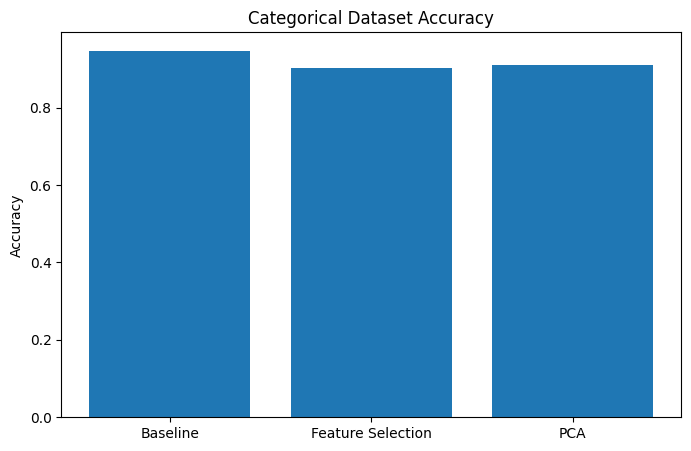

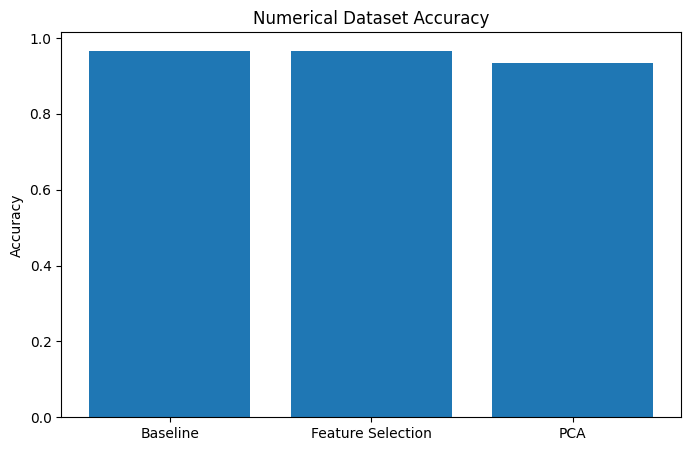

In [77]:
methods = ["Baseline", "Feature Selection", "PCA"]

cat_scores = [baseline_acc_categorical, fs_acc_cat, best_acc_cat]

num_scores = [baseline_acc_num, fs_acc_num, best_acc_num]


plt.figure(figsize=(8,5))

plt.bar(methods, cat_scores)


plt.title("Categorical Dataset Accuracy")

plt.ylabel("Accuracy")


plt.show()


plt.figure(figsize=(8,5))

plt.bar(methods, num_scores)

plt.title("Numerical Dataset Accuracy")

plt.ylabel("Accuracy")

plt.show()